# DSN Bootcamp Qualification Hackathon 2026 ML Track: Primrose's KNN approach

## Problem and approach
DSN Mart needs a sales estimate for each product-store record in the test set. The training file provides 6,818 observed `total_sales` values and the test file has 1,705 rows to predict. RMSE measures the gap between predictions and observed sales, giving larger errors more weight.

I study the product and outlet patterns, then use the original Big Mart data as a reference set. For each DSN row, the model looks at original records from the same store and category and predicts sales from the nearest records in price, weight, and shelf visibility. A Random Forest trained on DSN rows provides a second workflow for comparison.



Name: Olanudun Oluwapelumi

## 1. Read the data
I load the two DSN splits and the original Big Mart file. The path settings accept standard filenames and the uploaded copies.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

def first_existing(*names):
    return next((Path(name) for name in names if Path(name).exists()), Path(names[0]))

original_path = first_existing(
    "train (14).csv",   #https://www.kaggle.com/datasets/shivan118/big-mart-sales-prediction-datasets?select=train.csv
)
train_path = first_existing(
    "train.csv", "upload/train.csv", "upload/train(20260926-213709).csv"
)
test_path = first_existing(
    "test.csv"
)
original = pd.read_csv(original_path)
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
print("Original:", original.shape, "Train:", train.shape, "Test:", test.shape)


Original: (8523, 12) Train: (6818, 13) Test: (1705, 12)


The original file contains 8,523 records. DSN train has 6,818 and test has 1,705, which also total 8,523. The training file includes `total_sales`; test withholds it. That row-count relationship makes the original data a useful reference, while the actual neighbour selection will rely on store, category, price, weight, and visibility.

## 2. Make the two datasets comparable
The original file records store establishment year, while DSN records store age. I calculate age with the dataset's 2032 reference year, put location tiers in the same text format, and standardize category capitalization. Missing weights are filled with the median for that product and then the overall median if needed. The KNN distance requires complete numeric inputs.

In [2]:
original["age"] = 2032 - original["Outlet_Establishment_Year"]
original["tier"] = original["Outlet_Location_Type"].str.replace(" ", "_", regex=False)
original["category"] = original["Item_Type"].str.lower().str.strip()
original["weight"] = original["Item_Weight"].fillna(
    original.groupby("Item_Identifier")["Item_Weight"].transform("median")
).fillna(original["Item_Weight"].median())

all_dsn = pd.concat([train, test], ignore_index=True)
all_dsn["age"] = all_dsn["store_age_years"]
all_dsn["tier"] = all_dsn["store_location_tier"]
all_dsn["category"] = all_dsn["product_category"].str.lower().str.strip()
all_dsn["weight"] = all_dsn["product_weight_kg"].fillna(
    all_dsn.groupby("product_code")["product_weight_kg"].transform("median")
).fillna(all_dsn["product_weight_kg"].median())
print("Missing prepared weights:", original.weight.isna().sum(), all_dsn.weight.isna().sum())


Missing prepared weights: 0 0


Both prepared weight columns have zero missing values. Product-level medians use repeated appearances of the same item across stores, preserving more item-specific information than a single overall fill. Age, tier, and cleaned category now define comparable store-category groups in the two datasets.

In [3]:
# Check whether every DSN row has an original store-category group to search.
source_group_size = original.groupby(['age', 'tier', 'category']).size().rename('candidates')
all_dsn['candidate_count'] = pd.MultiIndex.from_frame(
    all_dsn[['age', 'tier', 'category']]
).map(source_group_size)
print('DSN rows without a source group:', int(all_dsn.candidate_count.isna().sum()))
print('Candidate rows per DSN record:')
print(all_dsn.candidate_count.describe().round(1).to_string())
print('Rows with fewer than three candidates:', int((all_dsn.candidate_count < 3).sum()))

DSN rows without a source group: 0
Candidate rows per DSN record:
count    8523.0
mean       81.1
std        38.3
min         4.0
25%        52.0
50%        75.0
75%       120.0
max       143.0
Rows with fewer than three candidates: 0


Every DSN row has a source group. The smallest group has four candidate records, the median has 75, and the largest has 143. This matters for the chosen three-neighbour setting: each row has at least three original records in the same age, tier, and category group before price, weight, and visibility decide which are closest.

## 3. Audit the target and missing fields
Before modelling, I check repeated IDs, product and store counts, raw missingness, and the range of sales. A product can appear in more than one store, but each product-store row should have its own ID.

In [4]:
print("Training rows:", len(train), "Test rows:", len(test))
print("Products:", train.product_code.nunique(), "Stores:", train.store_code.nunique())
print("Repeated train IDs:", train.id.duplicated().sum())
print("Repeated test IDs:", test.id.duplicated().sum())
print("Missing values by training column:", train.isna().sum().to_string())
print("Sales summary:", train.total_sales.describe().round(2).to_string())
print("Example rows:", train.head(3).to_string(index=False))


Training rows: 6818 Test rows: 1705
Products: 1555 Stores: 10
Repeated train IDs: 0
Repeated test IDs: 0
Missing values by training column: id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
Sales summary: count     6818.00
mean      2174.76
std       1697.89
min         32.70
25%        834.79
50%       1790.89
75%       3092.59
max      12996.82
Example rows:        id product_code  product_weight_kg fat_content  shelf_visibility   product_category  product_price store_code  store_age_years store_size store_location_tier         store_format  total_sales
row_00000   PRD-PRFP9S             14.252     Low Fat            0.0271       Frozen Foods          81.37  STORE-AGY        

There are 1,555 product codes and ten stores in the labeled split, with no repeated row IDs. Raw weight is missing in 1,225 rows and store size in 1,919. Sales is complete and ranges from 32.70 to 12,996.82. The mean of 2,174.76 exceeds the median of 1,790.89, showing that a smaller set of high-sales records lifts the average. Those high values deserve attention because RMSE magnifies large misses.

## 4. Engineer features for the comparison model
Price per prepared kilogram and visibility relative to the category median give the Random Forest more ways to describe a product. The KNN model below uses the original price, prepared weight, and visibility directly.

In [5]:
all_dsn["price_per_kg"] = all_dsn.product_price / all_dsn.weight
category_visibility = all_dsn.groupby("category").shelf_visibility.transform("median")
all_dsn["relative_visibility"] = all_dsn.shelf_visibility / category_visibility.clip(lower=0.001)
all_dsn["relative_visibility"] = all_dsn.relative_visibility.clip(upper=10)
print(all_dsn[["product_price", "weight", "price_per_kg", "shelf_visibility", "relative_visibility", "age"]].head())


   product_price  weight  price_per_kg  shelf_visibility  relative_visibility  \
0          81.37  14.252      5.709374            0.0271             0.473362   
1          42.05   7.698      5.462458            0.0720             1.607143   
2          41.35  14.264      2.898906            0.0421             0.825490   
3         174.35  12.665     13.766285            0.0449             0.925773   
4         203.06  10.338     19.642097            0.0120             0.261438   

   age  
0   45  
1   35  
2   33  
3   47  
4   28  


The first row has price 81.37 and prepared weight 14.252, giving a price-to-weight ratio of 5.71. Its visibility is 0.0271, about 47% of the median for its category. These fields may help the forest separate products, while the KNN will compare the underlying measurements in its distance calculation.

## 5. Explore sales across products and stores
I look at the sales distribution, mean sales and row counts by store format and category, and the relationships of price and visibility with sales. These patterns help decide whether a neighbour should come from the same outlet and product category.

Sales by store format:                         mean  count
store_format                       
Corner Shop            336.4    866
Superstore            1971.7    742
Standard Supermarket  2316.3   4462
Flagship Hypermarket  3660.2    748
Highest mean sales by category:                          mean  count
category                            
starchy foods          2407.7    113
household              2292.5    740
fruits and vegetables  2277.9   1006
meat                   2264.3    339
seafood                2262.5     52
dairy                  2238.3    554
snack foods            2223.8    933
canned                 2196.4    517
Price-sales correlation: 0.57
Visibility-sales correlation: -0.118


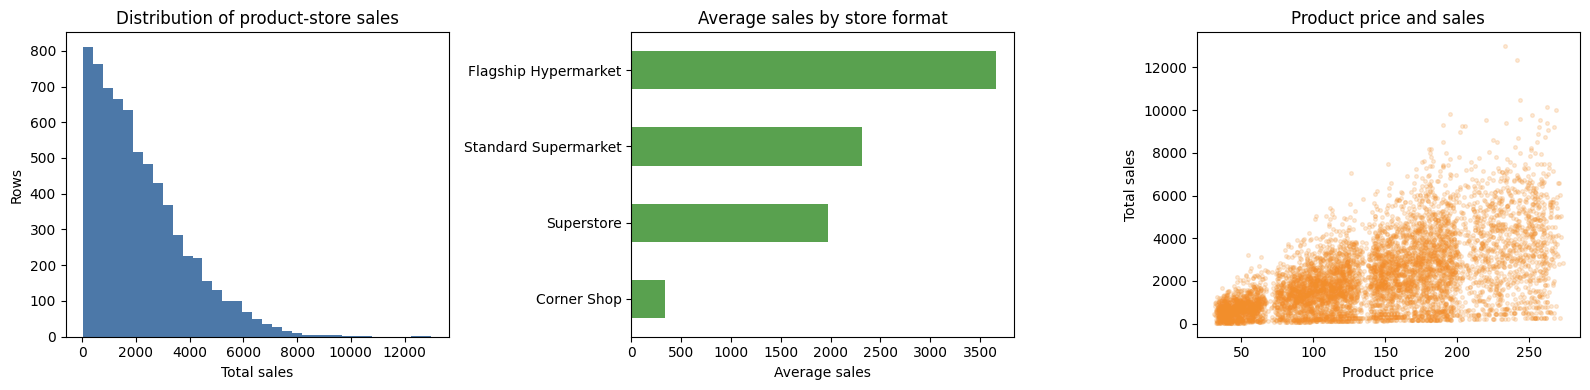

In [6]:
import matplotlib.pyplot as plt

store_summary = train.groupby("store_format").total_sales.agg(["mean", "count"]).sort_values("mean")
category_summary = (
    train.assign(category=train.product_category.str.lower().str.strip())
    .groupby("category").total_sales.agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)
print("Sales by store format:", store_summary.round(1).to_string())
print("Highest mean sales by category:", category_summary.head(8).round(1).to_string())
print("Price-sales correlation:", round(train.product_price.corr(train.total_sales), 3))
print("Visibility-sales correlation:", round(train.shelf_visibility.corr(train.total_sales), 3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(train.total_sales, bins=35, color="#4C78A8")
axes[0].set(title="Distribution of product-store sales", xlabel="Total sales", ylabel="Rows")
store_summary["mean"].plot.barh(ax=axes[1], color="#59A14F")
axes[1].set(title="Average sales by store format", xlabel="Average sales", ylabel="")
axes[2].scatter(train.product_price, train.total_sales, s=7, alpha=.18, color="#F28E2B")
axes[2].set(title="Product price and sales", xlabel="Product price", ylabel="Total sales")
plt.tight_layout()
plt.show()


The target has a long right tail. Corner Shops average 336.4 across 866 rows; Flagship Hypermarkets average 3,660.2 across 748. Standard Supermarkets account for the largest share of labeled rows at 4,462. Those differences make store context central to the search for comparable sales records.

Starchy Foods has the highest displayed category mean at 2,407.7 but only 113 rows, while Fruits and Vegetables has 1,006 rows at a mean of 2,277.9. Price is moderately associated with sales (correlation 0.57), whereas visibility is weakly negative (-0.118). The charts suggest comparing products within store and category first, then measuring closeness in price, weight, and visibility.

## 6. Define the nearest-neighbour model
For every DSN row, I restrict the reference set to the same store age, location tier, and cleaned category in the original file. Within that group, price, prepared weight, and shelf visibility are divided by fixed scales so their numeric ranges are comparable. The model takes a distance-weighted average of the three nearest source sales values.

In [7]:
def predict_with_knn(rows, price_scale=3.5, weight_scale=0.25,
                     visibility_scale=0.006, k=1):
    predictions = np.empty(len(rows), dtype=float)
    for (age, tier, category), group in rows.groupby(["age", "tier", "category"]):
        reference = original[
            (original.age == age) &
            (original.tier == tier) &
            (original.category == category)
        ]
        if reference.empty:
            raise ValueError(f"No original records for {(age, tier, category)}")
        source_features = np.column_stack([
            reference.Item_MRP / price_scale,
            reference.weight / weight_scale,
            reference.Item_Visibility / visibility_scale,
        ])
        query_features = np.column_stack([
            group.product_price / price_scale,
            group.weight / weight_scale,
            group.shelf_visibility / visibility_scale,
        ])
        model = KNeighborsRegressor(
            n_neighbors=min(k, len(reference)), weights="distance"
        )
        model.fit(source_features, reference.Item_Outlet_Sales)
        predictions[group.index.to_numpy()] = model.predict(query_features)
    return predictions


The function returns predictions in the original DSN row order. The exact group match prevents a similar-priced item in a different outlet or category from becoming a neighbour. `k=3` is supplied in the evaluation cell, so each estimate draws on three nearby reference rows, with the closest receiving the most weight.

## 7. Evaluate the KNN predictions
I use a fixed 20% sample of the labeled DSN rows to measure RMSE. The same prediction procedure is applied to all DSN rows, including the test split. This check measures how well nearest original sales values correspond to the DSN targets.

In [8]:
train_ids, holdout_ids = train_test_split(
    np.arange(len(train)), test_size=0.20, random_state=42
)
model_settings = {
    "price_scale": 3.5,
    "weight_scale": 0.25,
    "visibility_scale": 0.006,
    "k": 3,
}
all_predictions = predict_with_knn(all_dsn, **model_settings)
train_predictions = all_predictions[:len(train)]
holdout_rmse = np.sqrt(mean_squared_error(
    train.total_sales.iloc[holdout_ids], train_predictions[holdout_ids]
))
full_train_rmse = np.sqrt(mean_squared_error(
    train.total_sales, train_predictions
))
print("Three-neighbour held-out RMSE:", round(holdout_rmse, 2))
print("All DSN training rows RMSE:", round(full_train_rmse, 2))


Three-neighbour held-out RMSE: 378.56
All DSN training rows RMSE: 377.72


The three-neighbour model scores 378.56 RMSE on the 20% check and 377.72 across all labeled rows. The two totals are close, which suggests the sampled rows give a similar aggregate error to the full labeled set. The source reference contains counterparts to the DSN rows, so this is a check of the source-neighbour workflow rather than a test on entirely new products or outlets.

In [9]:
# Examine where the held-out errors occur.
validation = train.iloc[holdout_ids].copy()
validation['prediction'] = train_predictions[holdout_ids]
validation['absolute_error'] = (validation['prediction'] - validation['total_sales']).abs()
validation['squared_error'] = (validation['prediction'] - validation['total_sales']) ** 2
validation['price_quartile'] = pd.qcut(
    validation['product_price'], 4, labels=['Lowest', 'Lower-middle', 'Upper-middle', 'Highest']
)
format_error = validation.groupby('store_format').agg(
    rows=('id', 'size'), rmse=('squared_error', lambda x: np.sqrt(x.mean())),
    median_absolute_error=('absolute_error', 'median')
).round(2)
price_error = validation.groupby('price_quartile', observed=True).agg(
    rows=('id', 'size'), rmse=('squared_error', lambda x: np.sqrt(x.mean()))
).round(2)
print('Held-out error by store format:')
print(format_error.to_string())
print('Held-out error by price quartile:')
print(price_error.to_string())
print('Median absolute error:', round(validation.absolute_error.median(), 2))

Held-out error by store format:
                      rows    rmse  median_absolute_error
store_format                                             
Corner Shop            177   53.10                  19.76
Flagship Hypermarket   140  410.77                 157.65
Standard Supermarket   902  406.74                 160.07
Superstore             145  390.65                 150.76
Held-out error by price quartile:
                rows    rmse
price_quartile              
Lowest           341  130.77
Lower-middle     341  274.46
Upper-middle     341  453.96
Highest          341  524.14
Median absolute error: 127.07


The held-out error is smallest for Corner Shops, about 53 RMSE, and around 391 to 411 for the other formats. In absolute sales units, error also grows with price: about 131 RMSE in the lowest price quartile versus 524 in the highest. The median absolute error is about 127. These patterns are consistent with the earlier sales spread: high-value records create more room for a large absolute miss. They point to where the neighbour approach still loses precision.

## 8. Compare a feature-based model
As a second approach, I one-hot encode product and store categories and fit a Random Forest on 80% of the labeled DSN rows. It uses price, weight, visibility, age, the two engineered features, and store and product descriptors. I score it on the same 20% row indices.

In [10]:
from sklearn.ensemble import RandomForestRegressor

numeric_features = [
    "product_price", "weight", "shelf_visibility", "age",
    "price_per_kg", "relative_visibility"
]
category_features = ["category", "fat_content", "store_code", "store_format", "tier"]
forest_features = pd.get_dummies(
    all_dsn[numeric_features + category_features],
    columns=category_features, dtype=float
)
forest = RandomForestRegressor(
    n_estimators=150, min_samples_leaf=4, random_state=42, n_jobs=-1
)
forest.fit(forest_features.iloc[train_ids], train.total_sales.iloc[train_ids])
forest_holdout = forest.predict(forest_features.iloc[holdout_ids])
forest_rmse = np.sqrt(mean_squared_error(train.total_sales.iloc[holdout_ids], forest_holdout))
comparison = pd.DataFrame({
    "Model": ["KNN, original data, 3 neighbours", "Random Forest, DSN train only"],
    "Validation RMSE": [holdout_rmse, forest_rmse],
})
print(comparison.round(2).to_string(index=False))
print("Submission choice: three-neighbour KNN")


                           Model  Validation RMSE
KNN, original data, 3 neighbours           378.56
   Random Forest, DSN train only          1107.22
Submission choice: three-neighbour KNN


The Random Forest scores 1,107.22 RMSE versus 378.56 for the source-based three-neighbour model on this split. The comparison reflects both the modelling method and the information supplied: KNN searches the original dataset's sales records, while the forest learns only from DSN training rows. For this submission, the source-neighbour workflow has the lower local error, so the CSV uses its predictions.

In [11]:
# Inspect the forest's strongest encoded predictors.
importance = pd.Series(forest.feature_importances_, index=forest_features.columns)
print(importance.sort_values(ascending=False).head(8).round(3).to_string())

product_price               0.454
store_format_Corner Shop    0.225
weight                      0.045
price_per_kg                0.044
age                         0.043
shelf_visibility            0.043
relative_visibility         0.040
store_code_STORE-7WS        0.028


The forest's largest single importance is product price (about 0.454), followed by the Corner Shop indicator (about 0.225). This echoes the EDA finding that price and store format distinguish sales levels. Feature importance describes how this particular fitted forest uses its inputs; it does not explain the KNN score, whose predictions come from source-row proximity.

## 9. Generate the submission
I take the KNN predictions for the test rows, keep test IDs in their original order, replace any negative predictions with zero, and write the required two-column CSV.

In [12]:
test_predictions = all_predictions[len(train):]
submission = pd.DataFrame({
    "id": test.id.to_numpy(),
    "total_sales": np.maximum(test_predictions, 0),
})
assert len(submission) == len(test)
assert submission.id.tolist() == test.id.tolist()
assert submission.total_sales.notna().all()
output_file = Path("primrose_dsn.csv")
submission.to_csv(output_file, index=False)
print("Saved", output_file, "with", len(submission), "rows")
print(submission.head())


Saved primrose_dsn.csv with 1705 rows
          id  total_sales
0  row_00009  2186.423752
1  row_00015  4456.300205
2  row_00019  4174.741706
3  row_00020  2515.393213
4  row_00023  3829.075150


The output file has 1,705 predictions and the exact `id,total_sales` header. The row count, ID order, and missing-value checks all pass. The first five rows give a quick inspection of the values; `primrose_dsn.csv` contains the full set for submission.

## Conclusion
The data show a right-skewed target, large differences between store formats, and a positive price-sales relationship. Those patterns led to a nearest-neighbour search within the same store and product category, using scaled price, weight, and visibility to identify three close source records. This approach reached 378.56 RMSE on the local 20% check and produced predictions for all 1,705 test rows. The error analysis shows that the largest absolute misses tend to occur in the higher price ranges.